In [33]:
%load_ext autoreload
%autoreload 2

import os, ctypes
from glob import glob
append_ld_library_path = "~/.local/lib/python3.10/site-packages/nvidia/cublas/lib"
LD_LIBRARY_PATH = os.environ.get("LD_LIBRARY_PATH", "")
os.environ["LD_LIBRARY_PATH"] = f"{append_ld_library_path}:{LD_LIBRARY_PATH}" if LD_LIBRARY_PATH else append_ld_library_path

cublas_dir = "/home/ubuntu/.local/lib/python3.10/site-packages/nvidia/cublas/lib"
for pat in ["libcublas.so*", "libcublasLt.so*", "libcudart.so*"]:
    for lib in sorted(glob(os.path.join(cublas_dir, pat))):
        try:
            ctypes.CDLL(lib, mode=ctypes.RTLD_GLOBAL)
        except OSError as e:
            print(f"Warning: could not load {lib}: {e}")

import numpy as np
import pandas as pd
import pickle
import torch
import gc
import matplotlib.pyplot as plt
import time
from tqdm import tqdm

from pathlib import Path
from datetime import datetime
from scipy.optimize import linear_sum_assignment
from huggingface_hub import snapshot_download
from Bio import pairwise2
from scipy.spatial.distance import pdist, squareform

from MSA_Pairformer.dataset import esmtok_to_pairformertok_d, aa2tok_d
from MSA_Pairformer.model import MSAPairformer
from MSA_Pairformer.regression import MRFHead
from MSA_Pairformer.utils import get_coords, get_coords_cif
from MSA_Pairformer.plotting import eval_hetero_oligomer
from MSA_Pairformer.utils import get_p_at_k, get_p_at_l


from MSA_Pairformer.pairing_optimization.mp_em import MP_EM
from MSA_Pairformer.pairing_optimization.mp_pdp import MP_PDP
from MSA_Pairformer.pairing_optimization.msa_parsing import read_msa
from MSA_Pairformer.pairing_optimization.datasets import generate_dataset, dataset_tokenizer

import esm

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# Set device and load MSA Pairformer to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
msa_pairformer = MSAPairformer.from_pretrained(
    device=device
)
msa_pairformer.eval()

Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

Using cuEquivariance for triangle multiplicative update


MSAPairformer(
  (relative_position_encoding): RelativePositionEncoding(
    (out_embedder): Linear(in_features=139, out_features=256, bias=False)
  )
  (token_bond_to_pairwise_feat): Sequential(
    (0): Rearrange('... -> ... 1')
    (1): Linear(in_features=1, out_features=256, bias=False)
  )
  (msa_init_proj): Linear(in_features=28, out_features=464, bias=False)
  (core_stack): CoreModule(
    (layers): ModuleList(
      (0-21): 22 x ModuleList(
        (0): MSAPairWeightedAveraging(
          (msa_to_values_and_gates): Sequential(
            (0): LayerNorm((464,), eps=1e-05, elementwise_affine=True)
            (1): Linear(in_features=464, out_features=512, bias=False)
            (2): Rearrange('b s n (gv h d) -> gv b h s n d', gv=2, h=8)
          )
          (pairwise_repr_to_attn): Sequential(
            (0): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
            (1): Linear(in_features=256, out_features=8, bias=False)
            (2): Rearrange('b i j h -> b h i j

In [30]:
def align_and_map_chain(msa_seq, crystal_seq, msa_start_pos, cif_start_pos):
    """
    Align MSA sequence to crystal sequence and create position mapping
    """
    contact_threshold = 8
    # Global alignment with match/mismatch scoring
    alignments = pairwise2.align.globalms(
        msa_seq, crystal_seq,
        match=2,      # Match score
        mismatch=-1,  # Mismatch penalty
        open=-2,      # Gap open penalty
        extend=-0.5   # Gap extension penalty
    )
    
    best_alignment = alignments[0]
    aligned_msa, aligned_crystal = best_alignment[0], best_alignment[1]
    
    msa_to_crystal = {}
    crystal_to_msa = {}
    
    msa_pos = msa_start_pos
    crystal_pos = cif_start_pos
    
    for msa_char, crystal_char in zip(aligned_msa, aligned_crystal):
        if msa_char != '-' and crystal_char != '-':
            # Both sequences have residues at this position
            msa_to_crystal[msa_pos] = crystal_pos
            crystal_to_msa[crystal_pos] = msa_pos
            msa_pos += 1
            crystal_pos += 1
        elif msa_char != '-':
            # MSA has residue, crystal doesn't (insertion in MSA relative to crystal)
            msa_pos += 1
        elif crystal_char != '-':
            # Crystal has residue, MSA doesn't (insertion in crystal relative to MSA)
            crystal_pos += 1
    
    return msa_to_crystal, crystal_to_msa, best_alignment

def get_contact_map(chain_data_d, chain_1_id, chain_2_id, chain_1_chains_l, chain_2_chains_l):
    contact_threshold = 8
    # Get chain lengths
    chain_1_length = len(chain_data_d[chain_1_id]['cb_coordinates'])
    chain_2_length = len(chain_data_d[chain_2_id]['cb_coordinates'])
    # Create distogram
    # Hetero-oligomer interface contacts
    xyz_a = np.concatenate(
        [
            np.array(chain_data_d[chain_1_id]['cb_coordinates']),
            np.array(chain_data_d[chain_2_id]['cb_coordinates'])
        ]
    )
    chain_2_start_idx = chain_1_length
    # Compute distance matrix
    dist = squareform(pdist(xyz_a))
    # Compute contact map
    contacts_a = dist < 8
    contacts_a = contacts_a.astype(np.int64)
    contacts_a[np.isnan(dist)] = -1

    # Chain 1 homo-oligomer contacts
    if len(chain_1_chains_l) > 1:
        xyz_a_l = []
        final_homo_contacts_a = np.zeros((chain_1_length, chain_1_length)).astype(np.int64)
        residue_indices_a = np.array(chain_data_d[chain_1_id]['residue_indices']) # Residue indices of the main chain
        shift_idx = np.min([0, np.min(residue_indices_a-1)]) * -1 # Shift the residue indices to be positive (starts from at least 1)
        residue_indices_a = residue_indices_a + shift_idx
        max_residue_idx = np.max(residue_indices_a) # Maximum residue index of the main chain
        for chain_id in chain_1_chains_l:
            curr_chain_residue_indices_a = np.array(chain_data_d[chain_id]['residue_indices']) + shift_idx # Get residue indices of the secondary chain and shift
            chain_max_res_idx = np.max(curr_chain_residue_indices_a) # Maximum residue index of the secondary chain
            if chain_max_res_idx > max_residue_idx: # Extra chain is longer than the main chain
                xyz_a = np.nan * np.ones((chain_max_res_idx, 3))
                for i, res_idx in enumerate(curr_chain_residue_indices_a):
                    if res_idx >= 1:
                        xyz_a[res_idx-1] = chain_data_d[chain_id]['cb_coordinates'][i]
                xyz_a = xyz_a[residue_indices_a - 1, :]
            else: # Main chain is at least as long as the secondary chain
                xyz_a = np.nan * np.ones((max_residue_idx, 3))
                for i, res_idx in enumerate(curr_chain_residue_indices_a):
                    if res_idx >= 1:
                        xyz_a[res_idx-1] = chain_data_d[chain_id]['cb_coordinates'][i]
                xyz_a = xyz_a[residue_indices_a - 1, :]
            assert xyz_a.shape[0] == final_homo_contacts_a.shape[0]
            # Add coordinates to list
            xyz_a_l.append(xyz_a)
        xyz_a = np.concatenate(xyz_a_l)
        dist = squareform(pdist(xyz_a))
        homo_contacts_a = dist <= contact_threshold
        homo_contacts_a = homo_contacts_a.astype(np.int64)
        homo_contacts_a[np.isnan(dist)] = 0
        for i in range(len(chain_1_chains_l)): 
            final_homo_contacts_a = (
                final_homo_contacts_a | 
                homo_contacts_a[i*chain_1_length:(i+1)*chain_1_length, i*chain_1_length:(i+1)*chain_1_length]
            )
            for j in range(i+1, len(chain_1_chains_l)):
                final_homo_contacts_a = (
                    final_homo_contacts_a | 
                    homo_contacts_a[i*chain_1_length:(i+1)*chain_1_length, j*chain_1_length:(j+1)*chain_1_length] |
                    homo_contacts_a[j*chain_1_length:(j+1)*chain_1_length, i*chain_1_length:(i+1)*chain_1_length]
                )
        contacts_a[:chain_1_length, :chain_1_length] = final_homo_contacts_a
    # Chain 2 homo-oligomer contacts
    if len(chain_2_chains_l) > 1:
        xyz_a_l = []
        final_homo_contacts_a = np.zeros((chain_2_length, chain_2_length)).astype(np.int64)
        residue_indices_a = np.array(chain_data_d[chain_2_id]['residue_indices']) # Residue indices of the main chain
        shift_idx = np.min([0, np.min(residue_indices_a-1)]) * -1 # Shift the residue indices to be positive (starts from at least 1)
        residue_indices_a = residue_indices_a + shift_idx
        max_residue_idx = np.max(residue_indices_a) # Maximum residue index of the main chain
        for chain_id in chain_2_chains_l:
            curr_chain_residue_indices_a = np.array(chain_data_d[chain_id]['residue_indices']) + shift_idx # Get residue indices of the secondary chain and shift
            chain_max_res_idx = np.max(curr_chain_residue_indices_a) # Maximum residue index of the secondary chain
            if chain_max_res_idx > max_residue_idx: # Extra chain is longer than the main chain
                xyz_a = np.nan * np.ones((chain_max_res_idx, 3))
                for i, res_idx in enumerate(curr_chain_residue_indices_a):
                    if res_idx >= 1:
                        xyz_a[res_idx-1] = chain_data_d[chain_id]['cb_coordinates'][i]
                xyz_a = xyz_a[residue_indices_a - 1, :]
            else: # Main chain is at least as long as the secondary chain
                xyz_a = np.nan * np.ones((max_residue_idx, 3))
                for i, res_idx in enumerate(curr_chain_residue_indices_a):
                    if res_idx >= 1:
                        xyz_a[res_idx-1] = chain_data_d[chain_id]['cb_coordinates'][i]
                xyz_a = xyz_a[residue_indices_a - 1, :]
            assert xyz_a.shape[0] == final_homo_contacts_a.shape[0]
            # Add coordinates to list
            xyz_a_l.append(xyz_a)
        xyz_a = np.concatenate(xyz_a_l)
        dist = squareform(pdist(xyz_a))
        homo_contacts_a = dist <= contact_threshold
        homo_contacts_a = homo_contacts_a.astype(np.int64)
        homo_contacts_a[np.isnan(dist)] = 0
        for i in range(len(chain_2_chains_l)): 
            final_homo_contacts_a = (
                final_homo_contacts_a | 
                homo_contacts_a[i*chain_2_length:(i+1)*chain_2_length, i*chain_2_length:(i+1)*chain_2_length]
            )
            for j in range(i+1, len(chain_2_chains_l)):
                final_homo_contacts_a = (
                    final_homo_contacts_a | 
                    homo_contacts_a[i*chain_2_length:(i+1)*chain_2_length, j*chain_2_length:(j+1)*chain_2_length] |
                    homo_contacts_a[j*chain_2_length:(j+1)*chain_2_length, i*chain_2_length:(i+1)*chain_2_length]
                )
        contacts_a[chain_2_start_idx:, chain_2_start_idx:] = final_homo_contacts_a
    return contacts_a
    
chain_break_d = {
    "3A0R_A_3A0R_D": 349,
}
homooligomer_chains_d = {
    "3A0R_A_3A0R_D": (['A', 'A-2'], ['B-2', 'B']),
}
msa_mask_d = {}
cif_mask_d = {}
subset_chain_break_d = {}
contact_map_d = {}
# Load crystal contacts
with open("../../data/Figure2_heterooligomer_contact_prediction/target_data.pkl", "rb") as oFile:
    target_data_d = pickle.load(oFile)
target_id = "3A0R_A_3A0R_D"
# Get matching indices for MSA sequence and crystal structure
chain_break_pos = chain_break_d[target_id]
chain_1 = target_data_d[target_id]['chains'][0]
chain_2 = target_data_d[target_id]['chains'][1]
msa2cif1_d, cif2msa1_d, alignments1 = align_and_map_chain(target_data_d[target_id]['query_seq'][:chain_break_pos], target_data_d[target_id]['chain_data_d'][chain_1]['sequence'], 0, 0)
msa2cif2_d, cif2msa2_d, alignments2 = align_and_map_chain(target_data_d[target_id]['query_seq'][chain_break_pos:], target_data_d[target_id]['chain_data_d'][chain_2]['sequence'], chain_break_pos, len(target_data_d[target_id]['chain_data_d'][chain_1]['sequence']))
msa_mask_a = np.zeros(len(target_data_d[target_id]['query_seq'])).astype(bool)
msa_mask_a[list(msa2cif1_d.keys()) + list(msa2cif2_d.keys())] = True
cif_mask_a = np.zeros(len(target_data_d[target_id]['chain_data_d'][chain_1]['sequence']) + len(target_data_d[target_id]['chain_data_d'][chain_2]['sequence'])).astype(bool)
cif_mask_a[list(cif2msa1_d.keys()) + list(cif2msa2_d.keys())] = True
msa_mask_d[target_id] = msa_mask_a
cif_mask_d[target_id] = cif_mask_a
subset_chain_break_d[target_id] = np.max(list(msa2cif1_d.keys()))
assert msa_mask_a.sum() == cif_mask_a.sum()
# Check that residue indices list and coordinates list are the same length
for chain in target_data_d[target_id]['chain_data_d']:
    assert len(target_data_d[target_id]['chain_data_d'][chain]['residue_indices']) == len(target_data_d[target_id]['chain_data_d'][chain]['cb_coordinates'])
# Check whether any residue indices are negative
for chain in target_data_d[target_id]['chains']:
    if not all(np.array(target_data_d[target_id]['chain_data_d'][chain]['residue_indices']) >= 0):
        print(f"Residue indices must be non-negative for {target_id} chain {chain}")

# Get contact maps (consider homo-oligomer contacts wherever relevant)
chain_1_id = target_data_d[target_id]['chains'][0]
chain_2_id = target_data_d[target_id]['chains'][1]
chain_1_chains_l = homooligomer_chains_d[target_id][0]
chain_2_chains_l = homooligomer_chains_d[target_id][1]
contacts_a = get_contact_map(target_data_d[target_id]['chain_data_d'], chain_1_id="A", chain_2_id="B", chain_1_chains_l=chain_1_chains_l, chain_2_chains_l=chain_2_chains_l)
contacts2_a = get_contact_map(target_data_d[target_id]['chain_data_d'], chain_1_id="A", chain_2_id="B-2", chain_1_chains_l=chain_1_chains_l, chain_2_chains_l=chain_2_chains_l)
contacts3_a = get_contact_map(target_data_d[target_id]['chain_data_d'], chain_1_id="A-2", chain_2_id="B", chain_1_chains_l=chain_1_chains_l, chain_2_chains_l=chain_2_chains_l)
contacts4_a = get_contact_map(target_data_d[target_id]['chain_data_d'], chain_1_id="A-2", chain_2_id="B-2", chain_1_chains_l=chain_1_chains_l, chain_2_chains_l=chain_2_chains_l)
final_hk_rr_contacts_a = contacts_a | contacts2_a | contacts3_a | contacts4_a

In [31]:
# Get contacts from MALG-MALK crystal structure 2R6G
cif_file_path = "../../data/Figure3_toxin_antitoxin/2R6G-assembly1.cif"
malg_coords_a, malg_cif_seq, malg_res_idx_l = get_coords_cif(cif_file_path, "E")
malk_coords_a, malk_cif_seq, malk_res_idx_l = get_coords_cif(cif_file_path, "A")
malg_malk_seq = "ARMRFPGKATLLKGMLIFQMFPAVLSLVALYALFDRLGEYIPFIGLNTHGGVIFAYLGGIALHVWTIKGYFETIDSSLEEAAALDGATPWQAFRLVLLPLSVPILAVVFILSFIAAITEVPVASLLLRDVNSYTLAVGMQQYLNPQNYLWGDFAAAAVMSALPITIVFLLAQRWLVNKDINLDIHEGEFVVFVGPSGCGKSTLLRMIAGLETITSGDLFIGEKRMNDTPPAERGVGMVFQSYALYPHLSVAENMSFGLKLAGAKKEVINQRVNQVAEVLQLAHLLDRKPKALSGGQRQRVAIGRTLVAEPSVFLLDEPL"
malg_seq = malg_malk_seq[:177]
malk_seq = malg_malk_seq[177:]
malg_cif_mask = np.zeros(len(malg_cif_seq), dtype=bool)
malk_cif_mask = np.zeros(len(malk_cif_seq), dtype=bool)
malg_start_idx = malg_cif_seq.index(malg_seq)
malg_cif_mask[malg_start_idx:malg_start_idx+len(malg_seq)] = True
malk_cif_mask[18:18+len(malk_seq)] = True

malg_coords_a = malg_coords_a[malg_cif_mask]
malk_coords_a = malk_coords_a[malk_cif_mask]

malg_dist_a = np.linalg.norm(malg_coords_a[:, None] - malg_coords_a, axis=-1)
malk_dist_a = np.linalg.norm(malk_coords_a[:, None] - malk_coords_a, axis=-1)
true_malg_malk_cons_a = np.zeros((len(malg_malk_seq), len(malg_malk_seq)))
true_malg_malk_cons_a[:len(malg_seq), :len(malg_seq)] = malg_dist_a.copy()
true_malg_malk_cons_a[len(malg_seq):, len(malg_seq):] = malk_dist_a.copy()
malg_malk_dist_a = np.linalg.norm(malg_coords_a[:, None] - malk_coords_a, axis=-1)
true_malg_malk_cons_a[:len(malg_seq), len(malg_seq):] = malg_malk_dist_a.copy()
true_malg_malk_cons_a[len(malg_seq):, :len(malg_seq)] = np.linalg.norm(malk_coords_a[:, None] - malg_coords_a, axis=-1)
true_malg_malk_cons_a = true_malg_malk_cons_a < 8

# 1. Predict contacts using the optimized alignments
## 1.1 MP-EM

In [13]:
q = 400
precision_d = {}
contact_d = {}
gt_contact_d = {}
random_contact_d = {}
for target in ["hk_rr", "malg_malk"]:
    precision_d[target] = {}
    contact_d[target] = {}
    gt_contact_d[target] = {}
    random_contact_d[target] = {}
    if target == "hk_rr":
        msa_data = [read_msa("../../data/Figure3_toxin_antitoxin/HK_in_Concat_nnn.fasta", -1),
                    read_msa("../../data/Figure3_toxin_antitoxin/RR_in_Concat_nnn.fasta", -1)]
        get_species_name = (lambda strn: strn.split("|")[1])
        nSeqs = 384
        RESULTS_DIR = "results/pairing/hk_rr_384/"
    else:
        msa_data = [read_msa("../../data/Figure3_toxin_antitoxin/MALG_cov75_hmmsearch_extr5000_withLast_b.fasta", -1),
                    read_msa("../../data/Figure3_toxin_antitoxin/MALK_cov75_hmmsearch_extr5000_withLast_b.fasta", -1)]
        get_species_name = (lambda strn: strn.split("_")[-1])
        nSeqs = 256
        RESULTS_DIR = "results/pairing/malg_malk_256/"

    for seed in range(5):
        parameters_dataset = {
            "N": nSeqs,  # Average number of sequences in the input
            "pos": 0,  # Size of the context pairs to use as positive example 
            "max_size": 100,  # Max size of species MSAs (if same as N there is no limit on size)
            "NUMPY_SEED": seed,
            "NUMPY_SEED_OTHER": seed,
        }
        dataset, species_sizes = generate_dataset(
            parameters_dataset, msa_data, get_species_name=get_species_name, verbose=False
        )
        all_seq_set = set()
        filtered_dataset = {'msa': {'left': [], 'right': []}, 'positive_examples': None}
        for i in range(len(dataset['msa']['left'])):
            curr_seq = dataset['msa']['left'][i][1] + dataset['msa']['right'][i][1]
            if curr_seq not in all_seq_set:
                filtered_dataset['msa']['left'].append(dataset['msa']['left'][i])
                filtered_dataset['msa']['right'].append(dataset['msa']['right'][i])
                all_seq_set.add(curr_seq)
        curr_taxid = get_species_name(dataset['msa']['left'][0][0])
        curr_taxid_size = 1
        filtered_species_sizes = []
        solo_seq_idx_l = []
        for i in range(1, len(filtered_dataset['msa']['left'])):
            if get_species_name(filtered_dataset['msa']['left'][i][0]) == curr_taxid:
                curr_taxid_size += 1
            else:
                if curr_taxid_size == 1:
                    solo_seq_idx_l.append(i-1)
                filtered_species_sizes.append(curr_taxid_size)
                curr_taxid = get_species_name(filtered_dataset['msa']['left'][i][0])
                curr_taxid_size = 1
        filtered_species_sizes.append(curr_taxid_size)
        if curr_taxid_size == 1:
            solo_seq_idx_l.append(i)
        tokenized_dataset = dataset_tokenizer(filtered_dataset, device=device)
        # Get ESM tokens and convert to MSA Pairformer tokens
        esm_tokens_left = tokenized_dataset["msa"]["left"].argmax(dim=-1)
        esm_tokens_right = tokenized_dataset["msa"]["right"].argmax(dim=-1)
        # Remove singletons
        nonsingle_mask_t = torch.ones(esm_tokens_left.shape[1], dtype=torch.bool)
        nonsingle_mask_t[solo_seq_idx_l] = False
        esm_tokens_left = esm_tokens_left[:, nonsingle_mask_t, :]
        esm_tokens_right = esm_tokens_right[:, nonsingle_mask_t, :]
        filtered_species_sizes = np.array([s for s in filtered_species_sizes if s > 1])

        # Map ESM tokens to MSA Pairformer tokens and remove CLS token
        mp_tokenized_msa_left_t = torch.from_numpy(
            np.vectorize(esmtok_to_pairformertok_d.get)(esm_tokens_left.cpu().numpy())
        )[:, :, 1:].cpu()
        mp_tokenized_msa_right_t = torch.from_numpy(
            np.vectorize(esmtok_to_pairformertok_d.get)(esm_tokens_right.cpu().numpy())
        )[:, :, 1:].cpu()
        # One hot encode the tokens
        mp_ohe_msa_left_t = torch.nn.functional.one_hot(mp_tokenized_msa_left_t, num_classes=len(aa2tok_d)).to(torch.bfloat16).to(device)
        mp_ohe_msa_right_t = torch.nn.functional.one_hot(mp_tokenized_msa_right_t, num_classes=len(aa2tok_d)).to(torch.bfloat16).to(device)
        tokenized_dataset["msa"]["left"] = mp_ohe_msa_left_t # (1, N, L_left, 28)
        tokenized_dataset["msa"]["right"] = mp_ohe_msa_right_t # (1, N, L_right, 28)

        left_msa, right_msa = tokenized_dataset["msa"]["left"], tokenized_dataset["msa"]["right"]
        positive_examples = tokenized_dataset["positive_examples"] # empty

        # Designate the first sequence in the MSA as the query sequence
        # This will be a positive example and will be unchanged throughout optimization
        num_positive = 1
        positive_examples = torch.cat(
            (left_msa[:, :num_positive, :, :], right_msa[:, :num_positive, :, :]),
            dim=2
        ).to(device)
        left_msa_train = left_msa[:, num_positive:, :, :]
        right_msa_train = right_msa[:, num_positive:, :, :]
        filtered_species_sizes[0] = filtered_species_sizes[0] - 1
        # Make sure the first species has at least 2 sequences
        if filtered_species_sizes[0] < 2:
            filtered_species_sizes = filtered_species_sizes[1:]
            left_msa_train = left_msa_train[:, 1:, :, :]
            right_msa_train = right_msa_train[:, 1:, :, :]

        # Load results
        with open(Path(f"{RESULTS_DIR}/mp_em_results.seed_{seed}.pkl"), "rb") as f:
            res_d = pickle.load(f)
        losses = res_d['losses']
        perm_mats = res_d['perm_mats']
        # Get q lowest losses
        q_lowest_losses = np.argsort(losses)[:q]
        avg_perm_mat = torch.stack([perm_mats[i].to(torch.float32) for i in q_lowest_losses]).mean(dim=0)
        row_ind, col_ind = linear_sum_assignment(-avg_perm_mat)
        final_perm_mat = torch.zeros(sum(filtered_species_sizes), sum(filtered_species_sizes))
        final_perm_mat[row_ind, col_ind] = 1
        precision_d[target][seed] = np.trace(final_perm_mat) / np.sum(final_perm_mat.shape[0])
        # Construct MSAs
        permuted_left_msa = torch.einsum("pq,bprs->bqrs", (final_perm_mat.float().cpu(), left_msa_train.float().cpu()))
        combined_msa = torch.cat((permuted_left_msa, right_msa_train.cpu()), dim=2).to(device)
        combined_msa = torch.cat((positive_examples, combined_msa), dim=1).to(device)
        gt_combined_msa = torch.cat((left_msa_train, right_msa_train), dim=2).to(device)
        gt_combined_msa = torch.cat((positive_examples, gt_combined_msa), dim=1).to(device)
        random_permuted_left_msa = torch.einsum("pq,bprs->bqrs", (perm_mats[0].to(torch.float32).cpu(), left_msa_train.float().cpu()))
        random_combined_msa = torch.cat((random_permuted_left_msa, right_msa_train.cpu()), dim=2).to(device)
        random_combined_msa = torch.cat((positive_examples, random_combined_msa), dim=1).to(device)
        # Get contact map
        b, n, l, a = combined_msa.shape
        mask = torch.ones((b, l), device=device)
        msa_mask = torch.ones((b, n), device=device).bool()
        full_mask = torch.ones((b, n, l), device=device).bool()
        pairwise_mask = torch.ones((b, l, l), device=device).bool()
        with torch.no_grad():
            msa_pairformer.turn_off_query_biasing()
            with torch.amp.autocast(device_type=device.type, dtype=torch.bfloat16):
                pred_results = msa_pairformer(
                    combined_msa.to(torch.bfloat16),
                    mask = mask,
                    msa_mask = msa_mask,
                    full_mask = full_mask,
                    pairwise_mask = pairwise_mask,
                    return_cb_contacts=True,
                    return_seq_weights = False,
                    return_confind_contacts = False
                )
                random_pred_results = msa_pairformer(
                    random_combined_msa.to(torch.bfloat16),
                    mask = mask,
                    msa_mask = msa_mask,
                    full_mask = full_mask,
                    pairwise_mask = pairwise_mask,
                    return_cb_contacts=True,
                    return_seq_weights = False,
                    return_confind_contacts = False
                )
                gt_pred_results = msa_pairformer(
                    gt_combined_msa.to(torch.bfloat16),
                    mask = mask,
                    msa_mask = msa_mask,
                    full_mask = full_mask,
                    pairwise_mask = pairwise_mask,
                    return_cb_contacts=True,
                    return_seq_weights = False,
                    return_confind_contacts = False
                )
        contact_d[target][seed] = pred_results["predicted_cb_contacts"][0].cpu().numpy()
        random_contact_d[target][seed] = random_pred_results["predicted_cb_contacts"][0].cpu().numpy()
        gt_contact_d[target][seed] = gt_pred_results["predicted_cb_contacts"][0].cpu().numpy()
    print(f"{target} precision: {np.mean(list(precision_d[target].values()))}")
    print(f"{target} chain_break: {left_msa_train.shape[2]}")
with open("results/pairing/mp_em_predicted_contacts.pkl", "wb") as f:
    pickle.dump(contact_d, f)
with open("results/pairing/mp_em_pairing_precision.pkl", "wb") as f:
    pickle.dump(precision_d, f)
with open("results/pairing/random_predicted_contacts.pkl", "wb") as f:
    pickle.dump(random_contact_d, f)
with open("results/pairing/gt_predicted_contacts.pkl", "wb") as f:
    pickle.dump(gt_contact_d, f)
msa_pairformer.turn_on_query_biasing()

hk_rr precision: 0.6994702319977162
hk_rr chain_break: 64
malg_malk precision: 0.6668494972000681
malg_malk chain_break: 177


## 1.2 MP-PDP

In [8]:
q = 400
precision_d = {}
contact_d = {}
for target in ["hk_rr", "malg_malk"]:
    precision_d[target] = {}
    contact_d[target] = {}
    if target == "hk_rr":
        msa_data = [read_msa("../../data/Figure3_toxin_antitoxin/HK_in_Concat_nnn.fasta", -1),
                    read_msa("../../data/Figure3_toxin_antitoxin/RR_in_Concat_nnn.fasta", -1)]
        get_species_name = (lambda strn: strn.split("|")[1])
        nSeqs = 384
        RESULTS_DIR = "results/pairing/hk_rr_384_warm/"
    else:
        msa_data = [read_msa("../../data/Figure3_toxin_antitoxin/MALG_cov75_hmmsearch_extr5000_withLast_b.fasta", -1),
                    read_msa("../../data/Figure3_toxin_antitoxin/MALK_cov75_hmmsearch_extr5000_withLast_b.fasta", -1)]
        get_species_name = (lambda strn: strn.split("_")[-1])
        nSeqs = 256
        RESULTS_DIR = "results/pairing/malg_malk_256_warm/"

    for seed in range(5):
        parameters_dataset = {
            "N": nSeqs,  # Average number of sequences in the input
            "pos": 0,  # Size of the context pairs to use as positive example 
            "max_size": 100,  # Max size of species MSAs (if same as N there is no limit on size)
            "NUMPY_SEED": seed,
            "NUMPY_SEED_OTHER": seed,
        }
        dataset, species_sizes = generate_dataset(
            parameters_dataset, msa_data, get_species_name=get_species_name, verbose=False
        )
        all_seq_set = set()
        filtered_dataset = {'msa': {'left': [], 'right': []}, 'positive_examples': None}
        for i in range(len(dataset['msa']['left'])):
            curr_seq = dataset['msa']['left'][i][1] + dataset['msa']['right'][i][1]
            if curr_seq not in all_seq_set:
                filtered_dataset['msa']['left'].append(dataset['msa']['left'][i])
                filtered_dataset['msa']['right'].append(dataset['msa']['right'][i])
                all_seq_set.add(curr_seq)
        curr_taxid = get_species_name(dataset['msa']['left'][0][0])
        curr_taxid_size = 1
        filtered_species_sizes = []
        solo_seq_idx_l = []
        for i in range(1, len(filtered_dataset['msa']['left'])):
            if get_species_name(filtered_dataset['msa']['left'][i][0]) == curr_taxid:
                curr_taxid_size += 1
            else:
                if curr_taxid_size == 1:
                    solo_seq_idx_l.append(i-1)
                filtered_species_sizes.append(curr_taxid_size)
                curr_taxid = get_species_name(filtered_dataset['msa']['left'][i][0])
                curr_taxid_size = 1
        filtered_species_sizes.append(curr_taxid_size)
        if curr_taxid_size == 1:
            solo_seq_idx_l.append(i)
        tokenized_dataset = dataset_tokenizer(filtered_dataset, device=device)
        # Get ESM tokens and convert to MSA Pairformer tokens
        esm_tokens_left = tokenized_dataset["msa"]["left"].argmax(dim=-1)
        esm_tokens_right = tokenized_dataset["msa"]["right"].argmax(dim=-1)
        # Remove singletons
        nonsingle_mask_t = torch.ones(esm_tokens_left.shape[1], dtype=torch.bool)
        nonsingle_mask_t[solo_seq_idx_l] = False
        esm_tokens_left = esm_tokens_left[:, nonsingle_mask_t, :]
        esm_tokens_right = esm_tokens_right[:, nonsingle_mask_t, :]
        filtered_species_sizes = np.array([s for s in filtered_species_sizes if s > 1])

        # Map ESM tokens to MSA Pairformer tokens and remove CLS token
        mp_tokenized_msa_left_t = torch.from_numpy(
            np.vectorize(esmtok_to_pairformertok_d.get)(esm_tokens_left.cpu().numpy())
        )[:, :, 1:].cpu()
        mp_tokenized_msa_right_t = torch.from_numpy(
            np.vectorize(esmtok_to_pairformertok_d.get)(esm_tokens_right.cpu().numpy())
        )[:, :, 1:].cpu()
        # One hot encode the tokens
        mp_ohe_msa_left_t = torch.nn.functional.one_hot(mp_tokenized_msa_left_t, num_classes=len(aa2tok_d)).to(torch.bfloat16).to(device)
        mp_ohe_msa_right_t = torch.nn.functional.one_hot(mp_tokenized_msa_right_t, num_classes=len(aa2tok_d)).to(torch.bfloat16).to(device)
        tokenized_dataset["msa"]["left"] = mp_ohe_msa_left_t # (1, N, L_left, 28)
        tokenized_dataset["msa"]["right"] = mp_ohe_msa_right_t # (1, N, L_right, 28)

        left_msa, right_msa = tokenized_dataset["msa"]["left"], tokenized_dataset["msa"]["right"]
        positive_examples = tokenized_dataset["positive_examples"] # empty

        # Designate the first sequence in the MSA as the query sequence
        # This will be a positive example and will be unchanged throughout optimization
        num_positive = 1
        positive_examples = torch.cat(
            (left_msa[:, :num_positive, :, :], right_msa[:, :num_positive, :, :]),
            dim=2
        ).to(device)
        left_msa_train = left_msa[:, num_positive:, :, :]
        right_msa_train = right_msa[:, num_positive:, :, :]
        filtered_species_sizes[0] = filtered_species_sizes[0] - 1
        # Make sure the first species has at least 2 sequences
        if filtered_species_sizes[0] < 2:
            filtered_species_sizes = filtered_species_sizes[1:]
            left_msa_train = left_msa_train[:, 1:, :, :]
            right_msa_train = right_msa_train[:, 1:, :, :]

        # Load results
        with open(Path(f"{RESULTS_DIR}/mp_pdp_results.seed_{seed}.pkl"), "rb") as f:
            res_d = pickle.load(f)
        losses = res_d['losses']
        perm_mats = res_d['mat_perm']
        # Get q lowest losses
        q_lowest_losses = np.argsort(losses)[:q]
        avg_perm_mat = torch.stack([torch.from_numpy(perm_mats[i]).to(torch.float32) for i in q_lowest_losses]).mean(dim=0)
        row_ind, col_ind = linear_sum_assignment(-avg_perm_mat)
        final_perm_mat = torch.zeros_like(avg_perm_mat)
        final_perm_mat[row_ind, col_ind] = 1
        precision_d[target][seed] = np.trace(final_perm_mat) / np.sum(final_perm_mat.shape[0])
        # Get contact map
        permuted_left_msa = torch.einsum("pq,bprs->bqrs", (final_perm_mat.float().cpu(), left_msa_train.float().cpu()))
        combined_msa = torch.cat((permuted_left_msa, right_msa_train.cpu()), dim=2).to(device)
        combined_msa = torch.cat((positive_examples, combined_msa), dim=1).to(device)
        b, n, l, a = combined_msa.shape
        mask = torch.ones((b, l), device=device)
        msa_mask = torch.ones((b, n), device=device).bool()
        full_mask = torch.ones((b, n, l), device=device).bool()
        pairwise_mask = torch.ones((b, l, l), device=device).bool()
        with torch.no_grad():
            msa_pairformer.turn_off_query_biasing()
            with torch.amp.autocast(device_type=device.type, dtype=torch.bfloat16):
                pred_results = msa_pairformer(
                    combined_msa.to(torch.bfloat16),
                    mask = mask,
                    msa_mask = msa_mask,
                    full_mask = full_mask,
                    pairwise_mask = pairwise_mask,
                    return_cb_contacts=True,
                    return_seq_weights = False,
                    return_confind_contacts = False
                )
            msa_pairformer.turn_on_query_biasing()
        contact_d[target][seed] = pred_results["predicted_cb_contacts"][0].cpu().numpy()
    print(f"{target} precision: {np.mean(list(precision_d[target].values()))}")
    print(f"{target} chain_break: {left_msa_train.shape[2]}")
with open("results/pairing/predicted_contacts.mp_pdp_warmstart.pkl", "wb") as f:
    pickle.dump(contact_d, f)
with open("results/pairing/pairing_precision.mp_pdp_warmstart.pkl", "wb") as f:
    pickle.dump(precision_d, f)

hk_rr precision: 0.6750122644475696
hk_rr chain_break: 64
malg_malk precision: 0.697153122145411
malg_malk chain_break: 177


## 1.3 MSA Transformer DiffPALM

In [47]:
q = 400
precision_d = {}
contact_d = {}
for target in ["hk_rr", "malg_malk"]:
    precision_d[target] = {}
    contact_d[target] = {}
    if target == "hk_rr":
        msa_data = [read_msa("../../data/Figure3_toxin_antitoxin/HK_in_Concat_nnn.fasta", -1),
                    read_msa("../../data/Figure3_toxin_antitoxin/RR_in_Concat_nnn.fasta", -1)]
        get_species_name = (lambda strn: strn.split("|")[1])
        nSeqs = 384
        RESULTS_DIR = "results/pairing/hk_rr_384_warm_mt/"
    else:
        msa_data = [read_msa("../../data/Figure3_toxin_antitoxin/MALG_cov75_hmmsearch_extr5000_withLast_b.fasta", -1),
                    read_msa("../../data/Figure3_toxin_antitoxin/MALK_cov75_hmmsearch_extr5000_withLast_b.fasta", -1)]
        get_species_name = (lambda strn: strn.split("_")[-1])
        nSeqs = 256
        RESULTS_DIR = "results/pairing/malg_malk_256_warm_mt/"

    for seed in range(5):
        parameters_dataset = {
            "N": nSeqs,  # Average number of sequences in the input
            "pos": 0,  # Size of the context pairs to use as positive example 
            "max_size": 100,  # Max size of species MSAs (if same as N there is no limit on size)
            "NUMPY_SEED": seed,
            "NUMPY_SEED_OTHER": seed,
        }
        dataset, species_sizes = generate_dataset(
            parameters_dataset, msa_data, get_species_name=get_species_name, verbose=False
        )
        all_seq_set = set()
        filtered_dataset = {'msa': {'left': [], 'right': []}, 'positive_examples': None}
        for i in range(len(dataset['msa']['left'])):
            curr_seq = dataset['msa']['left'][i][1] + dataset['msa']['right'][i][1]
            if curr_seq not in all_seq_set:
                filtered_dataset['msa']['left'].append(dataset['msa']['left'][i])
                filtered_dataset['msa']['right'].append(dataset['msa']['right'][i])
                all_seq_set.add(curr_seq)
        curr_taxid = get_species_name(dataset['msa']['left'][0][0])
        curr_taxid_size = 1
        filtered_species_sizes = []
        solo_seq_idx_l = []
        for i in range(1, len(filtered_dataset['msa']['left'])):
            if get_species_name(filtered_dataset['msa']['left'][i][0]) == curr_taxid:
                curr_taxid_size += 1
            else:
                if curr_taxid_size == 1:
                    solo_seq_idx_l.append(i-1)
                filtered_species_sizes.append(curr_taxid_size)
                curr_taxid = get_species_name(filtered_dataset['msa']['left'][i][0])
                curr_taxid_size = 1
        filtered_species_sizes.append(curr_taxid_size)
        if curr_taxid_size == 1:
            solo_seq_idx_l.append(i)
        tokenized_dataset = dataset_tokenizer(filtered_dataset, device=device)
        # Get ESM tokens and convert to MSA Pairformer tokens
        esm_tokens_left = tokenized_dataset["msa"]["left"].argmax(dim=-1)
        esm_tokens_right = tokenized_dataset["msa"]["right"].argmax(dim=-1)
        # Remove singletons
        nonsingle_mask_t = torch.ones(esm_tokens_left.shape[1], dtype=torch.bool)
        nonsingle_mask_t[solo_seq_idx_l] = False
        esm_tokens_left = esm_tokens_left[:, nonsingle_mask_t, :]
        esm_tokens_right = esm_tokens_right[:, nonsingle_mask_t, :]
        filtered_species_sizes = np.array([s for s in filtered_species_sizes if s > 1])

        # Map ESM tokens to MSA Pairformer tokens and remove CLS token
        mp_tokenized_msa_left_t = torch.from_numpy(
            np.vectorize(esmtok_to_pairformertok_d.get)(esm_tokens_left.cpu().numpy())
        )[:, :, 1:].cpu()
        mp_tokenized_msa_right_t = torch.from_numpy(
            np.vectorize(esmtok_to_pairformertok_d.get)(esm_tokens_right.cpu().numpy())
        )[:, :, 1:].cpu()
        # One hot encode the tokens
        mp_ohe_msa_left_t = torch.nn.functional.one_hot(mp_tokenized_msa_left_t, num_classes=len(aa2tok_d)).to(torch.bfloat16).to(device)
        mp_ohe_msa_right_t = torch.nn.functional.one_hot(mp_tokenized_msa_right_t, num_classes=len(aa2tok_d)).to(torch.bfloat16).to(device)
        tokenized_dataset["msa"]["left"] = mp_ohe_msa_left_t # (1, N, L_left, 28)
        tokenized_dataset["msa"]["right"] = mp_ohe_msa_right_t # (1, N, L_right, 28)

        left_msa, right_msa = tokenized_dataset["msa"]["left"], tokenized_dataset["msa"]["right"]
        positive_examples = tokenized_dataset["positive_examples"] # empty

        # Designate the first sequence in the MSA as the query sequence
        # This will be a positive example and will be unchanged throughout optimization
        num_positive = 1
        positive_examples = torch.cat(
            (left_msa[:, :num_positive, :, :], right_msa[:, :num_positive, :, :]),
            dim=2
        ).to(device)
        left_msa_train = left_msa[:, num_positive:, :, :]
        right_msa_train = right_msa[:, num_positive:, :, :]
        filtered_species_sizes[0] = filtered_species_sizes[0] - 1
        # Make sure the first species has at least 2 sequences
        if filtered_species_sizes[0] < 2:
            filtered_species_sizes = filtered_species_sizes[1:]
            left_msa_train = left_msa_train[:, 1:, :, :]
            right_msa_train = right_msa_train[:, 1:, :, :]

        # Load results
        with open(Path(f"{RESULTS_DIR}/results.seed_{seed}.pkl"), "rb") as f:
            res_d = pickle.load(f)
        losses = res_d['losses']
        perm_mats = res_d['mat_perm']
        # Get q lowest losses
        q_lowest_losses = np.argsort(losses)[:q]
        avg_perm_mat = torch.stack([torch.from_numpy(perm_mats[i]).to(torch.float32) for i in q_lowest_losses]).mean(dim=0)
        row_ind, col_ind = linear_sum_assignment(-avg_perm_mat)
        final_perm_mat = torch.zeros_like(avg_perm_mat)
        final_perm_mat[row_ind, col_ind] = 1
        precision_d[target][seed] = np.trace(final_perm_mat) / np.sum(final_perm_mat.shape[0])
        # Get contact map
        permuted_left_msa = torch.einsum("pq,bprs->bqrs", (final_perm_mat.float().cpu(), left_msa_train.float().cpu()))
        combined_msa = torch.cat((permuted_left_msa, right_msa_train.cpu()), dim=2).to(device)
        combined_msa = torch.cat((positive_examples, combined_msa), dim=1).to(device)
        b, n, l, a = combined_msa.shape
        mask = torch.ones((b, l), device=device)
        msa_mask = torch.ones((b, n), device=device).bool()
        full_mask = torch.ones((b, n, l), device=device).bool()
        pairwise_mask = torch.ones((b, l, l), device=device).bool()
        with torch.no_grad():
            msa_pairformer.turn_off_query_biasing()
            with torch.amp.autocast(device_type=device.type, dtype=torch.bfloat16):
                pred_results = msa_pairformer(
                    combined_msa.to(torch.bfloat16),
                    mask = mask,
                    msa_mask = msa_mask,
                    full_mask = full_mask,
                    pairwise_mask = pairwise_mask,
                    return_cb_contacts=True,
                    return_seq_weights = False,
                    return_confind_contacts = False
                )
            msa_pairformer.turn_on_query_biasing()
        contact_d[target][seed] = pred_results["predicted_cb_contacts"][0].cpu().numpy()
    print(f"{target} precision: {np.mean(list(precision_d[target].values()))}")
    print(f"{target} chain_break: {left_msa_train.shape[2]}")
with open("results/pairing/predicted_contacts.msa_transformer_warmstart.pkl", "wb") as f:
    pickle.dump(contact_d, f)
with open("results/pairing/pairing_precision.msa_transformer_warmstart.pkl", "wb") as f:
    pickle.dump(precision_d, f)

hk_rr precision: 0.6265283466407083
hk_rr chain_break: 64
malg_malk precision: 0.31084771569482583
malg_malk chain_break: 177


# Figures 3EFG

HK-RR: MT vs Potts p=0.4050, MT vs EM p=0.0932
MALG-MALK: MT vs Potts p=0.0004, MT vs EM p=0.0004
Memory - HK-RR: MT=87.21GB, Potts=2.24GB, EM=1.29GB
Memory - MALG-MALK: MT=74.27GB, Potts=2.63GB, EM=2.70GB
Runtime - HK-RR: MT=18.39min, Potts=3.18min, EM=1.09min
Runtime - MALG-MALK: MT=18.17min, Potts=3.53min, EM=1.37min
Runtime p-values - HK-RR: MT vs Potts p=0.0000, Potts vs EM p=0.0000
Runtime p-values - MALG-MALK: MT vs Potts p=0.0000, Potts vs EM p=0.0000


/tmp/ipykernel_3937876/4234723206.py:268: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  fig.tight_layout()


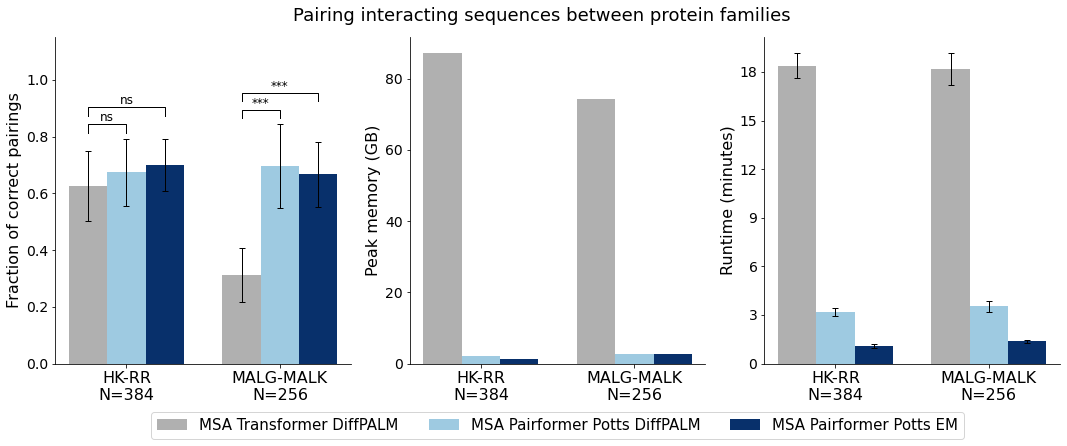

In [26]:
with open("results/pairing/pairing_precision.msa_transformer_warmstart.pkl", "rb") as f:
    mt_precision_d = pickle.load(f)
with open("results/pairing/pairing_precision.mp_pdp_warmstart.pkl", "rb") as f:
    mp_dp_precision_d = pickle.load(f)
with open("results/pairing/mp_em_pairing_precision.pkl", "rb") as f:
    mp_em_precision_d = pickle.load(f)

hk_rr_df = pd.DataFrame(index = ["MSA Transformer DiffPALM", "MSA Pairformer Potts DiffPALM", "MSA Pairformer EM"], columns = range(5))
malg_malk_df = pd.DataFrame(index = ["MSA Transformer DiffPALM", "MSA Pairformer Potts DiffPALM", "MSA Pairformer EM"], columns = range(5))
for seed in range(5):
    hk_rr_df.loc["MSA Transformer DiffPALM", seed] = mt_precision_d['hk_rr'][seed]
    hk_rr_df.loc["MSA Pairformer Potts DiffPALM", seed] = mp_dp_precision_d['hk_rr'][seed]
    hk_rr_df.loc["MSA Pairformer EM", seed] = mp_em_precision_d['hk_rr'][seed]
    malg_malk_df.loc["MSA Transformer DiffPALM", seed] = mt_precision_d['malg_malk'][seed]
    malg_malk_df.loc["MSA Pairformer Potts DiffPALM", seed] = mp_dp_precision_d['malg_malk'][seed]
    malg_malk_df.loc["MSA Pairformer EM", seed] = mp_em_precision_d['malg_malk'][seed]

# Calculate mean accuracy for each method
hk_rr_means = hk_rr_df.mean(axis=1)
malg_malk_means = malg_malk_df.mean(axis=1)

# Calculate standard error for each method
hk_rr_stds = hk_rr_df.std(axis=1)
malg_malk_stds = malg_malk_df.std(axis=1)
hk_rr_sems = hk_rr_stds #/ np.sqrt(hk_rr_df.shape[1])
malg_malk_sems = malg_malk_stds #/ np.sqrt(malg_malk_df.shape[1])

# Prepare data for bar plot
methods = ['MSA Transformer DiffPALM', 'MSA Pairformer Potts DiffPALM', 'MSA Pairformer EM']
hk_rr_values = [hk_rr_means.get(m, 0) for m in methods]
malg_malk_values = [malg_malk_means.get(m, 0) for m in methods]
hk_rr_errors = [hk_rr_sems.get(m, 0) for m in methods]
malg_malk_errors = [malg_malk_sems.get(m, 0) for m in methods]

# Load memory data
with open("results/pairing/malg_malk_256_warm_mt/memory_usage.pkl", "rb") as f:
    mt_malg_malk_memory_d = pickle.load(f)
with open("results/pairing/malg_malk_256_warm/mp_pdp_memory_usage.pkl", "rb") as f:
    mp_dp_malg_malk_memory_d = pickle.load(f)
with open("results/pairing/malg_malk_256/mp_em_memory_usage.pkl", "rb") as f:
    mp_em_malg_malk_memory_d = pickle.load(f)
with open("results/pairing/hk_rr_384_warm_mt/memory_usage.pkl", "rb") as f:
    mt_hk_rr_memory_d = pickle.load(f)
with open("results/pairing/hk_rr_384_warm/mp_pdp_memory_usage.pkl", "rb") as f:
    mp_dp_hk_rr_memory_d = pickle.load(f)
with open("results/pairing/hk_rr_384/mp_em_memory_usage.pkl", "rb") as f:
    mp_em_hk_rr_memory_d = pickle.load(f)

# Runtime per-run
malg_malk_runtime_d = {
    "MSA Transformer DiffPALM": [],
    "MSA Pairformer Potts DiffPALM": [],
    "MSA Pairformer EM": []
}
hk_rr_runtime_d = {
    "MSA Transformer DiffPALM": [],
    "MSA Pairformer Potts DiffPALM": [],
    "MSA Pairformer EM": []
}
for seed in range(5):
    # HK-RR
    with open(f"results/pairing/hk_rr_384_warm_mt/results.seed_{seed}.pkl", "rb") as f:
        res_d = pickle.load(f)
    hk_rr_runtime_d["MSA Transformer DiffPALM"].append(res_d['total_runtime'] / 60)
    with open(f"results/pairing/hk_rr_384_warm/mp_pdp_results.seed_{seed}.pkl", "rb") as f:
        res_d = pickle.load(f)
    hk_rr_runtime_d["MSA Pairformer Potts DiffPALM"].append(res_d['total_runtime'] / 60)
    with open(f"results/pairing/hk_rr_384/mp_em_results.seed_{seed}.pkl", "rb") as f:
        res_d = pickle.load(f)
    hk_rr_runtime_d["MSA Pairformer EM"].append(res_d['total_runtime'] / 60)
    # MALG-MALK
    # MSA Transformer runtime
    with open(f"results/pairing/malg_malk_256_warm_mt/results.seed_{seed}.pkl", "rb") as f:
        res_d = pickle.load(f)
    malg_malk_runtime_d["MSA Transformer DiffPALM"].append(res_d['total_runtime'] / 60)
    with open(f"results/pairing/malg_malk_256_warm/mp_pdp_results.seed_{seed}.pkl", "rb") as f:
        res_d = pickle.load(f)
    malg_malk_runtime_d["MSA Pairformer Potts DiffPALM"].append(res_d['total_runtime'] / 60)
    with open(f"results/pairing/malg_malk_256/mp_em_results.seed_{seed}.pkl", "rb") as f:
        res_d = pickle.load(f)
    malg_malk_runtime_d["MSA Pairformer EM"].append(res_d['total_runtime'] / 60)
malg_malk_runtime_df = pd.DataFrame(malg_malk_runtime_d, index = range(5)).T
hk_rr_runtime_df = pd.DataFrame(hk_rr_runtime_d, index = range(5)).T

hk_rr_memory_df = pd.DataFrame(index = ["MSA Transformer DiffPALM", "MSA Pairformer Potts DiffPALM", "MSA Pairformer EM"], columns = ['All runs'])
malg_malk_memory_df = pd.DataFrame(index = ["MSA Transformer DiffPALM", "MSA Pairformer Potts DiffPALM", "MSA Pairformer EM"], columns = ['All runs'])
hk_rr_memory_df.loc["MSA Transformer DiffPALM", 'All runs'] = mt_hk_rr_memory_d['incr_peak_resv_GB']
hk_rr_memory_df.loc["MSA Pairformer Potts DiffPALM", 'All runs'] = mp_dp_hk_rr_memory_d['incr_peak_resv_GB']
hk_rr_memory_df.loc["MSA Pairformer EM", 'All runs'] = mp_em_hk_rr_memory_d['incr_peak_resv_GB']
malg_malk_memory_df.loc["MSA Transformer DiffPALM", 'All runs'] = mt_malg_malk_memory_d['incr_peak_resv_GB']
malg_malk_memory_df.loc["MSA Pairformer Potts DiffPALM", 'All runs'] = mp_dp_malg_malk_memory_d['incr_peak_resv_GB']
malg_malk_memory_df.loc["MSA Pairformer EM", seed] = mp_em_malg_malk_memory_d['incr_peak_resv_GB']

# Define colors: light grey for MSA Transformer, lighter blue for Potts DiffPALM, darker blue for EM
colors = ['#B0B0B0', '#9ECAE1', '#08306B']  # light grey, light blue, dark blue

# Create figure with three subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

x = np.arange(2)  # Two groups: HK-RR and MALG-MALK
width = 0.25  # Width of bars

# Error bar line width
error_kw = {'elinewidth': 1, 'capthick': 1}

# --- Subplot 1: Accuracy ---
bars1 = ax1.bar(x - width, [hk_rr_values[0], malg_malk_values[0]], width, 
               yerr=[hk_rr_errors[0], malg_malk_errors[0]], capsize=3, label='MSA Transformer DiffPALM', color=colors[0], error_kw=error_kw)
bars2 = ax1.bar(x, [hk_rr_values[1], malg_malk_values[1]], width, 
               yerr=[hk_rr_errors[1], malg_malk_errors[1]], capsize=3, label='MSA Pairformer Potts DiffPALM', color=colors[1], error_kw=error_kw)
bars3 = ax1.bar(x + width, [hk_rr_values[2], malg_malk_values[2]], width, 
               yerr=[hk_rr_errors[2], malg_malk_errors[2]], capsize=3, label='MSA Pairformer Potts EM', color=colors[2], error_kw=error_kw)

# Statistical significance tests (paired t-tests)
from scipy import stats

def get_significance_symbol(p_value):
    if p_value < 0.001:
        return '***'
    elif p_value < 0.01:
        return '**'
    elif p_value < 0.05:
        return '*'
    else:
        return 'ns'

# HK-RR comparisons
hk_rr_mt_values = hk_rr_df.loc["MSA Transformer DiffPALM"].values.astype(float)
hk_rr_potts_values = hk_rr_df.loc["MSA Pairformer Potts DiffPALM"].values.astype(float)
hk_rr_em_values = hk_rr_df.loc["MSA Pairformer EM"].values.astype(float)

_, p_hk_rr_mt_potts = stats.ttest_rel(hk_rr_mt_values, hk_rr_potts_values)
_, p_hk_rr_mt_em = stats.ttest_rel(hk_rr_mt_values, hk_rr_em_values)

# MALG-MALK comparisons
malg_malk_mt_values = malg_malk_df.loc["MSA Transformer DiffPALM"].values.astype(float)
malg_malk_potts_values = malg_malk_df.loc["MSA Pairformer Potts DiffPALM"].values.astype(float)
malg_malk_em_values = malg_malk_df.loc["MSA Pairformer EM"].values.astype(float)

_, p_malg_malk_mt_potts = stats.ttest_rel(malg_malk_mt_values, malg_malk_potts_values)
_, p_malg_malk_mt_em = stats.ttest_rel(malg_malk_mt_values, malg_malk_em_values)

print(f"HK-RR: MT vs Potts p={p_hk_rr_mt_potts:.4f}, MT vs EM p={p_hk_rr_mt_em:.4f}")
print(f"MALG-MALK: MT vs Potts p={p_malg_malk_mt_potts:.4f}, MT vs EM p={p_malg_malk_mt_em:.4f}")

# Add significance bars for HK-RR (x=0)
def add_significance_bar(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, c='black')
    ax.text((x1+x2)/2, y+h, text, ha='center', va='bottom', fontsize=12)

# Get bar heights for positioning significance bars
y_max_hk_rr = max(hk_rr_values[0] + hk_rr_errors[0], hk_rr_values[1] + hk_rr_errors[1], hk_rr_values[2] + hk_rr_errors[2])
y_max_malg_malk = max(malg_malk_values[0] + malg_malk_errors[0], malg_malk_values[1] + malg_malk_errors[1], malg_malk_values[2] + malg_malk_errors[2])

# HK-RR significance bars (x=0)
h = 0.03
add_significance_bar(ax1, 0 - width, 0, y_max_hk_rr + 0.02, h, get_significance_symbol(p_hk_rr_mt_potts))
add_significance_bar(ax1, 0 - width, 0 + width, y_max_hk_rr + 0.08, h, get_significance_symbol(p_hk_rr_mt_em))

# MALG-MALK significance bars (x=1)
add_significance_bar(ax1, 1 - width, 1, y_max_malg_malk + 0.02, h, get_significance_symbol(p_malg_malk_mt_potts))
add_significance_bar(ax1, 1 - width, 1 + width, y_max_malg_malk + 0.08, h, get_significance_symbol(p_malg_malk_mt_em))

ax1.set_ylabel('Fraction of correct pairings', size=16)
# ax1.set_title('Pairing interacting sequences\nin protein families', size=16)
ax1.set_xticks(x)
ax1.set_xticklabels(['HK-RR\nN=384', 'MALG-MALK\nN=256'], size=16)
ax1.tick_params(axis='y', labelsize=14)
ax1.legend(fontsize=15, loc='upper center', bbox_to_anchor=(1.7, -0.125), ncol=3)
ax1.set_ylim(0, 1.15)  # Increased to accommodate significance bars

# --- Subplot 2: Memory ---
hk_rr_memory_means = hk_rr_memory_df.astype(float).mean(axis=1)
malg_malk_memory_means = malg_malk_memory_df.astype(float).mean(axis=1)
hk_rr_memory_sems = hk_rr_memory_df.astype(float).std(axis=1) / np.sqrt(5)
malg_malk_memory_sems = malg_malk_memory_df.astype(float).std(axis=1) / np.sqrt(5)

hk_rr_memory_values = [hk_rr_memory_means.get(m, 0) for m in methods]
malg_malk_memory_values = [malg_malk_memory_means.get(m, 0) for m in methods]
hk_rr_memory_errors = [hk_rr_memory_sems.get(m, 0) for m in methods]
malg_malk_memory_errors = [malg_malk_memory_sems.get(m, 0) for m in methods]

ax2.bar(x - width, [hk_rr_memory_values[0], malg_malk_memory_values[0]], width, 
        label='MSA Transformer DiffPALM', color=colors[0])
ax2.bar(x, [hk_rr_memory_values[1], malg_malk_memory_values[1]], width, 
        label='MSA Pairformer Potts DiffPALM', color=colors[1])
ax2.bar(x + width, [hk_rr_memory_values[2], malg_malk_memory_values[2]], width, 
        label='MSA Pairformer Potts EM', color=colors[2])

ax2.set_ylabel('Peak memory (GB)', size=16)
# ax2.set_title('GPU memory usage', size=16)
ax2.set_xticks(x)
ax2.set_xticklabels(['HK-RR\nN=384', 'MALG-MALK\nN=256'], size=16)
ax2.tick_params(axis='y', labelsize=14)

# Memory statistical significance
hk_rr_memory_mt_values = hk_rr_memory_df.loc["MSA Transformer DiffPALM"].values.astype(float)
hk_rr_memory_potts_values = hk_rr_memory_df.loc["MSA Pairformer Potts DiffPALM"].values.astype(float)
hk_rr_memory_em_values = hk_rr_memory_df.loc["MSA Pairformer EM"].values.astype(float)

malg_malk_memory_mt_values = malg_malk_memory_df.loc["MSA Transformer DiffPALM"].values.astype(float)
malg_malk_memory_potts_values = malg_malk_memory_df.loc["MSA Pairformer Potts DiffPALM"].values.astype(float)
malg_malk_memory_em_values = malg_malk_memory_df.loc["MSA Pairformer EM"].values.astype(float)

# Print memory values with statistical significance
print(f"Memory - HK-RR: MT={hk_rr_memory_values[0]:.2f}GB, Potts={hk_rr_memory_values[1]:.2f}GB, EM={hk_rr_memory_values[2]:.2f}GB")
print(f"Memory - MALG-MALK: MT={malg_malk_memory_values[0]:.2f}GB, Potts={malg_malk_memory_values[1]:.2f}GB, EM={malg_malk_memory_values[2]:.2f}GB")

# --- Subplot 3: Runtime ---
hk_rr_runtime_means = hk_rr_runtime_df.mean(axis=1)
malg_malk_runtime_means = malg_malk_runtime_df.mean(axis=1)
hk_rr_runtime_sems = hk_rr_runtime_df.std(axis=1)# / np.sqrt(5)
malg_malk_runtime_sems = malg_malk_runtime_df.std(axis=1)# / np.sqrt(5)

hk_rr_runtime_values = [hk_rr_runtime_means.get(m, 0) for m in methods]
malg_malk_runtime_values = [malg_malk_runtime_means.get(m, 0) for m in methods]
hk_rr_runtime_errors = [hk_rr_runtime_sems.get(m, 0) for m in methods]
malg_malk_runtime_errors = [malg_malk_runtime_sems.get(m, 0) for m in methods]

ax3.bar(x - width, [hk_rr_runtime_values[0], malg_malk_runtime_values[0]], width, 
        yerr=[hk_rr_runtime_errors[0], malg_malk_runtime_errors[0]], capsize=3, label='MSA Transformer DiffPALM', color=colors[0], error_kw=error_kw)
ax3.bar(x, [hk_rr_runtime_values[1], malg_malk_runtime_values[1]], width, 
        yerr=[hk_rr_runtime_errors[1], malg_malk_runtime_errors[1]], capsize=3, label='MSA Pairformer Potts DiffPALM', color=colors[1], error_kw=error_kw)
ax3.bar(x + width, [hk_rr_runtime_values[2], malg_malk_runtime_values[2]], width, 
        yerr=[hk_rr_runtime_errors[2], malg_malk_runtime_errors[2]], capsize=3, label='MSA Pairformer Potts EM', color=colors[2], error_kw=error_kw)

ax3.set_ylabel('Runtime (minutes)', size=16)
# ax3.set_title('Runtime', size=16)
ax3.set_xticks(x)
ax3.set_xticklabels(['HK-RR\nN=384', 'MALG-MALK\nN=256'], size=16)
ax3.tick_params(axis='y', labelsize=14)
ax3.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Runtime statistical significance
hk_rr_runtime_mt_values = hk_rr_runtime_df.loc["MSA Transformer DiffPALM"].values.astype(float)
hk_rr_runtime_potts_values = hk_rr_runtime_df.loc["MSA Pairformer Potts DiffPALM"].values.astype(float)
hk_rr_runtime_em_values = hk_rr_runtime_df.loc["MSA Pairformer EM"].values.astype(float)

malg_malk_runtime_mt_values = malg_malk_runtime_df.loc["MSA Transformer DiffPALM"].values.astype(float)
malg_malk_runtime_potts_values = malg_malk_runtime_df.loc["MSA Pairformer Potts DiffPALM"].values.astype(float)
malg_malk_runtime_em_values = malg_malk_runtime_df.loc["MSA Pairformer EM"].values.astype(float)

# Print runtime values with statistical significance
print(f"Runtime - HK-RR: MT={hk_rr_runtime_values[0]:.2f}min, Potts={hk_rr_runtime_values[1]:.2f}min, EM={hk_rr_runtime_values[2]:.2f}min")
print(f"Runtime - MALG-MALK: MT={malg_malk_runtime_values[0]:.2f}min, Potts={malg_malk_runtime_values[1]:.2f}min, EM={malg_malk_runtime_values[2]:.2f}min")

# Statistical tests for runtime
# HK-RR: MT vs Potts
_, p_hk_mt_potts_runtime = stats.ttest_ind(hk_rr_runtime_mt_values, hk_rr_runtime_potts_values)
# HK-RR: Potts vs EM
_, p_hk_potts_em_runtime = stats.ttest_ind(hk_rr_runtime_potts_values, hk_rr_runtime_em_values)
# MALG-MALK: MT vs Potts
_, p_malg_mt_potts_runtime = stats.ttest_ind(malg_malk_runtime_mt_values, malg_malk_runtime_potts_values)
# MALG-MALK: Potts vs EM
_, p_malg_potts_em_runtime = stats.ttest_ind(malg_malk_runtime_potts_values, malg_malk_runtime_em_values)

print(f"Runtime p-values - HK-RR: MT vs Potts p={p_hk_mt_potts_runtime:.4f}, Potts vs EM p={p_hk_potts_em_runtime:.4f}")
print(f"Runtime p-values - MALG-MALK: MT vs Potts p={p_malg_mt_potts_runtime:.4f}, Potts vs EM p={p_malg_potts_em_runtime:.4f}")

fig.suptitle("Pairing interacting sequences between protein families", size=18, y=0.95)

# Remove top and right spines from each subplot
for ax in [ax1, ax2, ax3]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


fig.tight_layout()
fig.savefig("results/pairing_performance.pdf", dpi=300, bbox_inches='tight')

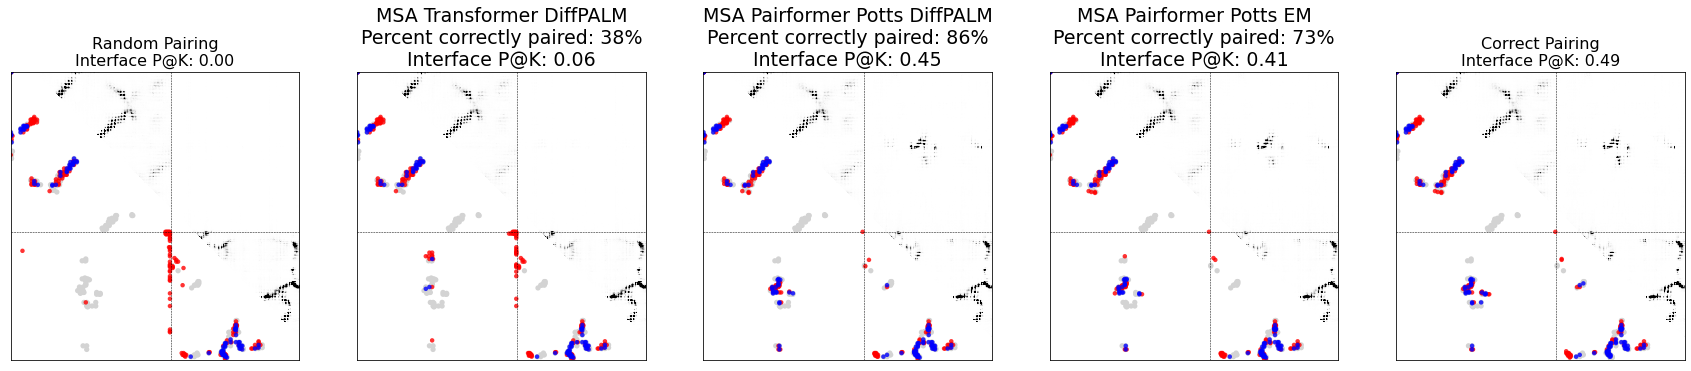

In [25]:
# Plot contact prediction
with open("results/pairing/predicted_contacts.msa_transformer_warmstart.pkl", "rb") as oFile:
    mt_predicted_contacts_d = pickle.load(oFile)
with open("results/pairing/predicted_contacts.mp_pdp_warmstart.pkl", "rb") as oFile:
    mp_dp_predicted_contacts_d = pickle.load(oFile)
with open("results/pairing/mp_em_predicted_contacts.pkl", "rb") as oFile:
    mp_em_predicted_contacts_d = pickle.load(oFile)
with open("results/pairing/random_predicted_contacts.pkl", "rb") as oFile:
    random_predicted_contacts_d = pickle.load(oFile)
with open("results/pairing/gt_predicted_contacts.pkl", "rb") as oFile:
    gt_predicted_contacts_d = pickle.load(oFile)

seed = 2
target = "malg_malk"
methods_l = ['Random Pairing', 'MSA Transformer DiffPALM', 'MSA Pairformer Potts DiffPALM', 'MSA Pairformer Potts EM', 'Correct Pairing']
pairing_precisions_l = [None, mt_precision_d[target][seed], mp_dp_precision_d[target][seed], mp_em_precision_d[target][seed], None]
pred_cons_l = [random_predicted_contacts_d[target][seed], mt_predicted_contacts_d[target][seed], mp_dp_predicted_contacts_d[target][seed], mp_em_predicted_contacts_d[target][seed], gt_predicted_contacts_d[target][seed]]

f, ax = plt.subplots(1, 5, figsize=(30, 6), facecolor='white')
for i, method in enumerate(methods_l):
    f, _, precision_d = eval_hetero_oligomer(
        cons = [true_malg_malk_cons_a, pred_cons_l[i]],
        chain_break_pos = len(malg_seq),
        L = 1,
        monomer_minsep = 24,
        cutoffs = [None, None],
        ss = [28, 20],
        cc = ['lightgrey', 'blue'],
        f = f,
        ax=ax[i],
        vmax = 0.3,
        vmin = 0,
        monomer_p_at_k = True,
    )
    if method not in ["Random Pairing", "Correct Pairing"]:
        # Show % correctly paired as a whole-number fraction
        correctly_paired_percent = int(round(pairing_precisions_l[i] * 100))
        ax[i].set_title(f"{method}\nPercent correctly paired: {correctly_paired_percent}%\nInterface P@K: {precision_d['interface']:.2f}", size=19)
 
    else:
        ax[i].set_title(f"{method}\nInterface P@K: {precision_d['interface']:.2f}", size=16)
    ax[i].axvline(len(malg_seq), color='black', linestyle='--', linewidth=0.5)
    ax[i].axhline(len(malg_seq), color='black', linestyle='--', linewidth=0.5)
f.savefig("results/pairing/malg_malk_contacts.seed_2.pdf", dpi=300, bbox_inches='tight')

Text(0.5, 1.0, 'MSA Pairformer Potts EM\nMALG-MALK')

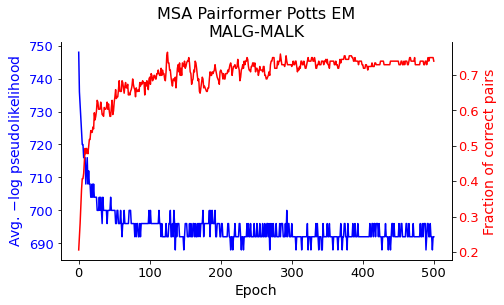

In [28]:
with open("results/pairing/malg_malk_256/mp_em_results.seed_2.pkl", "rb") as f:
    res_d = pickle.load(f)
losses = res_d['losses']
perm_mats = res_d['perm_mats']
frac_correct = [np.trace(perm_mat)/perm_mat.shape[0] for perm_mat in perm_mats]
f, ax1 = plt.subplots(1, 1, figsize=(7,4))
ax1.plot(losses, color='blue')
ax1.set_ylabel('Avg. $-$log pseudolikelihood', color='blue', size=14)
ax1.tick_params(axis='y', labelcolor='blue', labelsize=13)
ax1.tick_params(axis='x', labelsize=13)
ax1.spines['top'].set_visible(False)

ax2 = ax1.twinx()
ax2.plot(frac_correct, color='red')
ax2.set_ylabel('Fraction of correct pairs', color='red', size=14)
ax2.tick_params(axis='y', labelcolor='red', labelsize=13)
ax2.spines['top'].set_visible(False)
ax1.set_xlabel('Epoch', size=14)
ax1.set_title('MSA Pairformer Potts EM\nMALG-MALK', size=16)

In [40]:
# Plot contact prediction
with open("results/pairing/predicted_contacts.msa_transformer_warmstart.pkl", "rb") as oFile:
    mt_predicted_contacts_d = pickle.load(oFile)
with open("results/pairing/predicted_contacts.mp_pdp_warmstart.pkl", "rb") as oFile:
    mp_dp_predicted_contacts_d = pickle.load(oFile)
with open("results/pairing/mp_em_predicted_contacts.pkl", "rb") as oFile:
    mp_em_predicted_contacts_d = pickle.load(oFile)
with open("results/pairing/random_predicted_contacts.pkl", "rb") as oFile:
    random_predicted_contacts_d = pickle.load(oFile)
with open("results/pairing/gt_predicted_contacts.pkl", "rb") as oFile:
    gt_predicted_contacts_d = pickle.load(oFile)

p_at_k_d = {
    "Random Pairing": [],
    "MSA Transformer DiffPALM": [],
    "MSA Pairformer Potts DiffPALM": [],
    "MSA Pairformer Potts EM": [],
    "Correct Pairing": []
}
chain_break_pos = len(malg_seq)
for seed in range(5):
    target = "malg_malk"
    methods_l = ['Random Pairing', 'MSA Transformer DiffPALM', 'MSA Pairformer Potts DiffPALM', 'MSA Pairformer Potts EM', 'Correct Pairing']
    pairing_precisions_l = [0, mt_precision_d[target][seed], mp_dp_precision_d[target][seed], mp_em_precision_d[target][seed], 1]
    pred_cons_l = [random_predicted_contacts_d[target][seed], mt_predicted_contacts_d[target][seed], mp_dp_predicted_contacts_d[target][seed], mp_em_predicted_contacts_d[target][seed], gt_predicted_contacts_d[target][seed]]

    for i, method in enumerate(methods_l):
        hetero_p_at_k = get_p_at_k(true_malg_malk_cons_a[:chain_break_pos][:, chain_break_pos:], pred_cons_l[i][:chain_break_pos][:, chain_break_pos:], minsep=0, upper_triangle=False)
        p_at_k_d[method].append(hetero_p_at_k)
pd.DataFrame(p_at_k_d).mean(axis=0)

Random Pairing                   0.000000
MSA Transformer DiffPALM         0.016327
MSA Pairformer Potts DiffPALM    0.465306
MSA Pairformer Potts EM          0.444898
Correct Pairing                  0.571429
dtype: float64